# Eficácia do Pressing no Futebol de Elite — Análise de Gatilhos de pressão

## 1. Introdução

Este notebook busca apresentar uma análise da eficácia de determinados gatilhos de pressão no futebol de alto nível, complementando a análise geral de pressão, em especial após determinados tipos de passes e a consequência dos mesmos.

## 2. Configuração e Carregamento de Dados

In [60]:
import json
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [61]:
DATA_DIR = Path('StatsBomb_2/data')
if not DATA_DIR.exists():
    DATA_DIR = Path('C:\\Users\\DELL\\Downloads\\CDAF - bases de dados e codigos de apoio\\data\\archive\\data')

COMP_ID, SEASON_ID = 55, 43  # UEFA Euro 2020
FIELD_X, FIELD_Y = 120.0, 80.0

def load_json(path):
    with open(path, encoding='utf-8') as fh:
        return json.load(fh)

matches = load_json(DATA_DIR / 'matches' / str(COMP_ID) / (str(SEASON_ID) + '.json'))
match_ids = sorted(m['match_id'] for m in matches)

events_parts = []
frames = {}
for mid in match_ids:
    raw = load_json(DATA_DIR / 'events' / (str(mid) + '.json'))
    edf = pd.json_normalize(raw, sep='_')
    edf['match_id'] = mid
    events_parts.append(edf)
    ts_path = DATA_DIR / 'three-sixty' / (str(mid) + '.json')
    if ts_path.exists():
        for fr in load_json(ts_path):
            frames[fr['event_uuid']] = fr

events = pd.concat(events_parts, ignore_index=True)
def ts_to_seconds(ts):
    hh, mm, ss = ts.split(':')
    return int(hh) * 3600 + int(mm) * 60 + float(ss)

events['t'] = events['timestamp'].apply(ts_to_seconds)
events['t_match'] = events['minute'] * 60 + events['second']
print(f'Eventos carregados: {len(events)} | Frames 360: {len(frames)}')

Eventos carregados: 192692 | Frames 360: 166892


## 3. Escolha e Especificação de Gatilhos

É notável a ausência na literatura de estudos aprofundados que definam o que e como caracterizam gatilhos de pressão. Artigos como o de **Harrison (2025)** oferecem exemplos visuais de _triggers_ que aumentam a frequência de eventos de pressão, mas não justificam a escolha dos gatilhos. Por isso, este estudo foca em estabelecer critérios básicos para definir gatilhos que possam ser utilizados para a análise de eficácia.

É importante observar que, como os dados Statsbomb 360 utilizam-se de eventos para definir um _freeze frame_ da partida, uma análise que considere fatores como erros de domínio de bola e tentativas de drible, que também são fatores que podem se tornar gatilhos, não é considerada viável. Por isso, este notebook se dedica a estabelecer uma análise sólida e estruturada de diferentes gatilhos de passes.

### 3.1. Definição de um _Trigger_

Um evento de pressão no Statsbomb ocorre no instante em que um jogador estiver a um raio de 5 jardas de um adversário que tenha a posse da bola (**Merckx et al., 2021**). Uma pressão aplicada de um jogador sobre outro pode ser facilmente observável por esse evento, mas, para esta análise, será considerada uma pressão acionada por gatilho apenas aquela que, nos 5 segundos seguintes, gerar no mínimo outro evento de pressão por outro jogador ou recuperação de bola pela equipe que pressiona dentro de 5 metros do ponto da pressão, e não haver outro evento de pressão coletiva observado nos 5 segundos anteriores (para evitar pressões duplicadas).

Tendo esse evento de pressão coletiva definido, o gatilho será classificado a partir do passe que originou a pressão, de forma que consideramos apenas os eventos definidos de pressão coletiva que resultaram de um passe nos 6 segundos anteriores. Definimos como passes característicos de gerar _triggers_ como recuos, passes laterais onde não há progressão, passes próximos à linha lateral com bola rolando e passes especificamente destinados aos goleiros.

### 3.1.1. Recuos

São definidos como passes que têm como destino uma posição vertical inferior em relação à origem. para desconsiderar passes laterais comuns, são considerados apenas aqueles que regridem pelo menos 10 metros no campo.

### 3.1.2. Passes laterais sem progressão

Passes que têm pouco impacto no aspecto vertical do jogo. São analisados aqueles que percorrem ao menos 10 metros horizontalmente e menos de 10 metros verticalmente, tanto para frente quanto para trás.

### 3.1.3. Passes próximos à linha lateral

Passes cujo receptor está em até 5 metros de distância da linha lateral, excluindo cobranças de lateral.

### 3.1.4. Cobranças de lateral

Único tipo de bola parada analisada, já que gera pressão em grande parte das execuções.

### 3.1.5. Passes para o goleiro

Exemplo clássico de gatilho de pressão, precisa apenas de um jogador pressionando diferentemente dos outros, ocorre quando o jogador em posse no instante da pressão é o goleiro adversário.

### 3.1.6. Adversários sem companheiros de equipe próximos

Diferentemente dos outros, não depende dos eventos de passe. Ocorre quando não houver nenhum companheiro de equipe em um raio de 15m de distância do jogador com a bola.

In [62]:
#Separando os eventos de pressão
pressures = events[events['type_name'] == 'Pressure'].copy()
passes = events[events['type_name'] == 'Pass'].copy()
print(f'Eventos de pressão : {len(pressures)} \nEventos de passes: {len(passes)}')

Eventos de pressão : 15958 
Eventos de passes: 54819


In [ ]:
# Separando os eventos que caracterizam uma pressão coletiva

PRESSURE_WINDOW = 5
RECOVERY_MAX_DISTANCE = 5

pressures = pressures.sort_values(['match_id', 'period', 't', 'index']).copy()
pressures['pressure_event_id'] = pressures['id']
events_sorted = events.sort_values(['match_id', 'period', 't', 'index']).copy()

possession_team_col = None
for candidate_col in ['possession_team_name', 'possession_team']:
    if candidate_col in events_sorted.columns:
        possession_team_col = candidate_col
        break

RECOVERY_EVENT_TYPES = {
    'Ball Recovery',
    'Interception',
    'Duel',
    'Dribbled Past',
    'Miscontrol',
    'Dispossessed',
    'Error',
    'Clearance',
    'Block'
}

def get_events_after_pressure(row, df=events_sorted, window=PRESSURE_WINDOW):
    """Retorna eventos ocorridos após a pressão dentro da janela definida."""
    window_events = df[
        (df['match_id'] == row['match_id']) &
        (df['period'] == row['period']) &
        (df['t'] > row['t']) &
        (df['t'] <= row['t'] + window)
    ].copy()

    if 'index' in window_events.columns and 'index' in row.index and not pd.isna(row['index']):
        window_events = window_events[window_events['index'] > row['index']]

    return window_events

def has_next_team_pressure(row, df=pressures, window=PRESSURE_WINDOW):
    """Verifica se há nova pressão da mesma equipe por outro jogador nos 5s seguintes."""
    mask = (
        (df['match_id'] == row['match_id']) &
        (df['period'] == row['period']) &
        (df['team_name'] == row['team_name']) &
        (df['t'] > row['t']) &
        (df['t'] <= row['t'] + window) &
        (df['player_id'] != row['player_id'])
    )

    if 'index' in df.columns and 'index' in row.index and not pd.isna(row['index']):
        mask = mask & (df['index'] > row['index'])

    return bool(mask.any())

def has_recovery_within_window(row, window=PRESSURE_WINDOW):
    """Verifica se o time que pressiona recupera a posse nos 5s seguintes."""
    window_events = get_events_after_pressure(row, window=window)

    if window_events.empty:
        return False

    pressure_team = row['team_name']

    # Critério preferencial: a posse passa a ser da equipe que pressionou.
    if possession_team_col is not None:
        return bool(window_events[possession_team_col].eq(pressure_team).any())

    # Fallback: eventos explícitos de recuperação/interceptação/duelo da equipe que pressionou.
    own_recovery = window_events[
        (window_events['team_name'] == pressure_team) &
        (window_events['type_name'].isin(RECOVERY_EVENT_TYPES))
    ]
    if not own_recovery.empty:
        return True

    # Fallback mínimo: algum evento posterior da equipe que pressionou.
    return bool((window_events['team_name'] == pressure_team).any())

pressures['has_next_team_pressure_10s'] = pressures.apply(has_next_team_pressure, axis=1)
pressures['has_recovery_10s'] = pressures.apply(has_recovery_within_window, axis=1)
pressures['has_next_team_pressure_or_recovery_10s'] = (
    pressures['has_next_team_pressure_10s'] | pressures['has_recovery_10s']
)

team_pressures = pressures[pressures['has_next_team_pressure_or_recovery_10s']].copy()

print(f'Eventos com outra pressão por outro jogador em até 10s: {int(pressures["has_next_team_pressure_10s"].sum())}')
print(f'Eventos com recuperação em até 10s: {int(pressures["has_recovery_10s"].sum())}')
print(f'Eventos de pressão coletiva/efetiva: {len(team_pressures)}')

Eventos com outra pressão por outro jogador em até 10s: 6149
Eventos com recuperação em até 10s: 4948
Eventos de pressão coletiva/efetiva: 9574


In [64]:
# Filtrando os eventos de início de pressão coletiva
# Mantém apenas o primeiro evento de uma sequência, evitando duplicidade.

def has_previous_collective_pressure(row, df=team_pressures, window=PRESSURE_WINDOW):
    mask = (
        (df['match_id'] == row['match_id']) &
        (df['period'] == row['period']) &
        (df['team_name'] == row['team_name']) &
        (df['t'] < row['t']) &
        (df['t'] >= row['t'] - window)
    )
    return bool(mask.any())

team_pressures['has_previous_collective_pressure_10s'] = team_pressures.apply(
    has_previous_collective_pressure, axis=1
)

team_pressures_base = team_pressures[
    ~team_pressures['has_previous_collective_pressure_10s']
].copy()

print(f'Eventos de início pressão coletiva: {len(team_pressures_base)}')

Eventos de início pressão coletiva: 5687


In [65]:
# Selecionando apenas os eventos que são consequência de passes
# Para cada início de pressão coletiva, seleciona-se o passe adversário mais recente
# ocorrido até 6s antes do início da pressão.

PASS_TRIGGER_WINDOW = 6

passes = passes.sort_values(['match_id', 'period', 't', 'index']).copy()
completed_passes = passes[
    passes.get('pass_outcome_name', pd.Series(index=passes.index)).isna()
].copy()

def find_previous_opponent_pass(row, df=completed_passes, window=PASS_TRIGGER_WINDOW):
    cand = df[
        (df['match_id'] == row['match_id']) &
        (df['period'] == row['period']) &
        (df['team_name'] != row['team_name']) &
        (df['t'] >= row['t'] - window) &
        (df['t'] <= row['t'])
    ]
    if cand.empty:
        return pd.Series(dtype='object')
    return cand.sort_values(['t', 'index']).iloc[-1]

trigger_rows = []
for _, pressure_row in team_pressures_base.iterrows():
    pass_row = find_previous_opponent_pass(pressure_row)
    if pass_row.empty:
        continue

    combined = pressure_row.add_prefix('pressure_').to_dict()
    combined.update(pass_row.add_prefix('pass_').to_dict())
    combined['seconds_from_pass_to_pressure'] = pressure_row['t'] - pass_row['t']
    trigger_rows.append(combined)

passing_triggers = pd.DataFrame(trigger_rows)

print(f'Eventos de gatilhos de passe: {len(passing_triggers)}')

Eventos de gatilhos de passe: 3551


In [66]:
# Recuos
# Passes cuja coordenada x final é pelo menos 10m menor que a inicial.

MIN_BACKWARD_METERS = 10

def get_xy(value):
    if isinstance(value, (list, tuple, np.ndarray)) and len(value) >= 2:
        return float(value[0]), float(value[1])
    return np.nan, np.nan

if not passing_triggers.empty:
    passing_triggers[['pass_start_x', 'pass_start_y']] = passing_triggers['pass_location'].apply(
        lambda v: pd.Series(get_xy(v))
    )
    passing_triggers[['pass_end_x', 'pass_end_y']] = passing_triggers['pass_pass_end_location'].apply(
        lambda v: pd.Series(get_xy(v))
    )
    passing_triggers['pass_dx'] = passing_triggers['pass_end_x'] - passing_triggers['pass_start_x']
    passing_triggers['pass_dy'] = passing_triggers['pass_end_y'] - passing_triggers['pass_start_y']
else:
    for col in ['pass_start_x', 'pass_start_y', 'pass_end_x', 'pass_end_y', 'pass_dx', 'pass_dy']:
        passing_triggers[col] = pd.Series(dtype='float')

backpasses = passing_triggers[
    passing_triggers['pass_dx'] <= -MIN_BACKWARD_METERS
].copy()

print(f'Eventos de recuos: {len(backpasses)}')

Eventos de recuos: 251


In [67]:
# Passes laterais
# Passes com deslocamento horizontal relevante e baixa progressão/regressão:
# - pelo menos 10m no eixo y;
# - menos de 10m, em módulo, no eixo x.

MIN_HORIZONTAL_METERS = 10
MAX_VERTICAL_CHANGE_METERS = 10

lateral_passes = passing_triggers[
    (passing_triggers['pass_dy'].abs() >= MIN_HORIZONTAL_METERS) &
    (passing_triggers['pass_dx'].abs() < MAX_VERTICAL_CHANGE_METERS)
].copy()

print(f'Eventos de passes laterais: {len(lateral_passes)}')

Eventos de passes laterais: 857


In [68]:
# Passes próximos à linha lateral
# Exclui cobranças de lateral para manter apenas bola rolando.

# Receptor em até 5m de uma das linhas laterais.
SIDELINE_DISTANCE = 5
FIELD_Y = 80.0

pass_type_col = 'pass_pass_type_name'
is_throw_in_pass = (
    passing_triggers[pass_type_col].eq('Throw-in')
    if pass_type_col in passing_triggers.columns
    else pd.Series(False, index=passing_triggers.index)
)

sideline_passes = passing_triggers[
    (
        (passing_triggers['pass_end_y'] <= SIDELINE_DISTANCE) |
        (passing_triggers['pass_end_y'] >= FIELD_Y - SIDELINE_DISTANCE)
    ) &
    (~is_throw_in_pass)
].copy()

print(f'Eventos de passes próximos à linha lateral: {len(sideline_passes)}')

Eventos de passes próximos à linha lateral: 466


In [69]:
# Cobranças de lateral
# passes cujo tipo StatsBomb é Throw-in.

pass_type_col = 'pass_pass_type_name'

if pass_type_col in passing_triggers.columns:
    throw_ins = passing_triggers[
        passing_triggers[pass_type_col].eq('Throw-in')
    ].copy()
else:
    throw_ins = passing_triggers.iloc[0:0].copy()
    print("Coluna pass_pass_type_name não encontrada; não foi possível filtrar cobranças de lateral.")

print(f'Eventos de cobranças de lateral: {len(throw_ins)}')

Eventos de cobranças de lateral: 353


In [70]:
# Passes para o goleiro
# localiza-se o adversário mais próximo do pressionador no instante da pressão;
# se esse adversário for goleiro, é classificado como gatilho de pressão no goleiro.

def nearest_opponent_to_pressure(pressure_event_id, pressure_team_is_teammate=True):
    frame = frames.get(pressure_event_id)
    if not frame or 'freeze_frame' not in frame:
        return pd.Series({
            'ball_carrier_name': np.nan,
            'ball_carrier_is_keeper': np.nan,
            'ball_carrier_x': np.nan,
            'ball_carrier_y': np.nan,
            'ball_carrier_teammates_15m': np.nan
        })

    ff = frame['freeze_frame']

    actor = next((p for p in ff if p.get('actor')), None)
    if actor is None:
        return pd.Series({
            'ball_carrier_name': np.nan,
            'ball_carrier_is_keeper': np.nan,
            'ball_carrier_x': np.nan,
            'ball_carrier_y': np.nan,
            'ball_carrier_teammates_15m': np.nan
        })

    ax, ay = actor.get('location', [np.nan, np.nan])[:2]

    # No freeze frame, teammate=True costuma ser relativo à equipe do evento.
    # Como o evento é Pressure, teammate=False representa adversários pressionados.
    opponents = [p for p in ff if not p.get('teammate', False)]
    if not opponents:
        return pd.Series({
            'ball_carrier_name': np.nan,
            'ball_carrier_is_keeper': np.nan,
            'ball_carrier_x': np.nan,
            'ball_carrier_y': np.nan,
            'ball_carrier_teammates_15m': np.nan
        })

    def dist_to_actor(p):
        x, y = p.get('location', [np.nan, np.nan])[:2]
        return np.hypot(x - ax, y - ay)

    ball_carrier = min(opponents, key=dist_to_actor)
    bx, by = ball_carrier.get('location', [np.nan, np.nan])[:2]
    position_name = ball_carrier.get('position', {}).get('name', '')
    is_keeper = bool(ball_carrier.get('keeper', False)) or position_name == 'Goalkeeper'

    teammates_15m = 0
    for p in opponents:
        if p is ball_carrier:
            continue
        x, y = p.get('location', [np.nan, np.nan])[:2]
        if np.hypot(x - bx, y - by) <= 15:
            teammates_15m += 1

    return pd.Series({
        'ball_carrier_name': ball_carrier.get('player', {}).get('name', np.nan),
        'ball_carrier_is_keeper': is_keeper,
        'ball_carrier_x': bx,
        'ball_carrier_y': by,
        'ball_carrier_teammates_15m': teammates_15m
    })

if not passing_triggers.empty:
    pressure_ids = passing_triggers['pressure_id']
    ball_carrier_info = pressure_ids.apply(nearest_opponent_to_pressure)
    passing_triggers = pd.concat(
        [passing_triggers.reset_index(drop=True), ball_carrier_info.reset_index(drop=True)],
        axis=1
    )

gk_passes = passing_triggers[
    passing_triggers['ball_carrier_is_keeper'].fillna(False)
].copy()

print(f'Eventos de passes para o goleiro: {len(gk_passes)}')

Eventos de passes para o goleiro: 56


In [71]:
# Passe para jogador correndo para trás / pivô

PIVOT_SPEED_THRESHOLD = 1      # m/s
BACKWARD_VX_THRESHOLD = -5      # m/s
MIN_BODY_ANGLE_DT = 0.05          # evita divisão por zero/eventos simultâneos
MAX_BODY_ANGLE_DT = PASS_TRIGGER_WINDOW if 'PASS_TRIGGER_WINDOW' in globals() else 6


def _empty_receiver_motion_series(method='sem_dados'):
    return pd.Series({
        'receiver_estimated_x': np.nan,
        'receiver_estimated_y': np.nan,
        'receiver_pressure_x': np.nan,
        'receiver_pressure_y': np.nan,
        'receiver_motion_dt': np.nan,
        'receiver_vx': np.nan,
        'receiver_vy': np.nan,
        'receiver_speed': np.nan,
        'receiver_is_pivot': False,
        'receiver_running_backwards': False,
        'receiver_body_angle_trigger': False,
        'receiver_velocity_method': method
    })


def _nearest_opponent_location_from_pressure(pressure_event_id):
    """Retorna a localização do adversário mais próximo do jogador que pressiona."""
    frame = frames.get(pressure_event_id)
    if not frame or 'freeze_frame' not in frame:
        return None

    ff = frame['freeze_frame']
    actor = next((p for p in ff if p.get('actor')), None)
    if actor is None:
        return None

    actor_location = actor.get('location')
    if not isinstance(actor_location, (list, tuple)) or len(actor_location) < 2:
        return None

    ax, ay = actor_location[:2]
    if pd.isna(ax) or pd.isna(ay):
        return None

    # Em evento Pressure, teammate=False representa jogadores adversários ao time que pressiona.
    opponents = [p for p in ff if not p.get('teammate', False)]
    if not opponents:
        return None

    valid_opponents = []
    for p in opponents:
        loc = p.get('location')
        if isinstance(loc, (list, tuple)) and len(loc) >= 2:
            x, y = loc[:2]
            if not pd.isna(x) and not pd.isna(y):
                valid_opponents.append((p, float(x), float(y), float(np.hypot(x - ax, y - ay))))

    if not valid_opponents:
        return None

    _, x, y, dist = min(valid_opponents, key=lambda item: item[3])
    return x, y, dist


def receiver_motion_from_pass_to_pressure(row):
    """Estima deslocamento do receptor entre o fim do passe e o freeze-frame da pressão."""
    pressure_event_id = row.get('pressure_id', np.nan)
    pass_t = row.get('pass_t', np.nan)
    pressure_t = row.get('pressure_t', np.nan)

    pass_end_x = row.get('pass_end_x', np.nan)
    pass_end_y = row.get('pass_end_y', np.nan)

    if pd.isna(pass_end_x) or pd.isna(pass_end_y):
        # Fallback caso a célula de extração pass_end_x/pass_end_y não tenha sido executada.
        pass_end_x, pass_end_y = get_xy(row.get('pass_pass_end_location', np.nan))

    if pd.isna(pressure_event_id):
        return _empty_receiver_motion_series('sem_id_pressao')

    if pd.isna(pass_t) or pd.isna(pressure_t):
        return _empty_receiver_motion_series('sem_tempo')

    dt = pressure_t - pass_t
    if pd.isna(dt) or dt < MIN_BODY_ANGLE_DT or dt > MAX_BODY_ANGLE_DT:
        out = _empty_receiver_motion_series('delta_t_invalido_ou_distante')
        out['receiver_motion_dt'] = dt
        return out

    if pd.isna(pass_end_x) or pd.isna(pass_end_y):
        return _empty_receiver_motion_series('sem_posicao_final_do_passe')

    nearest = _nearest_opponent_location_from_pressure(pressure_event_id)
    if nearest is None:
        return _empty_receiver_motion_series('sem_adversario_no_frame_pressao')

    pressure_x, pressure_y, pressure_dist_to_actor = nearest

    vx = (pressure_x - float(pass_end_x)) / dt
    vy = (pressure_y - float(pass_end_y)) / dt
    speed = float(np.hypot(vx, vy))

    is_pivot = speed < PIVOT_SPEED_THRESHOLD
    running_backwards = vx < BACKWARD_VX_THRESHOLD

    return pd.Series({
        'receiver_estimated_x': float(pass_end_x),
        'receiver_estimated_y': float(pass_end_y),
        'receiver_pressure_x': pressure_x,
        'receiver_pressure_y': pressure_y,
        'receiver_motion_dt': dt,
        'receiver_vx': vx,
        'receiver_vy': vy,
        'receiver_speed': speed,
        'receiver_is_pivot': bool(is_pivot),
        'receiver_running_backwards': bool(running_backwards),
        'receiver_body_angle_trigger': bool(is_pivot or running_backwards),
        'receiver_velocity_method': 'pass_end_to_pressure_freeze_frame'
    })


if not passing_triggers.empty:
    receiver_velocity_info = passing_triggers.apply(receiver_motion_from_pass_to_pressure, axis=1)

    # Remove colunas antigas do gatilho corporal, caso a célula tenha sido executada antes.
    body_cols = [
        'receiver_player_id', 'receiver_player_name', 'receiver_x', 'receiver_y',
        'receiver_prev_x', 'receiver_prev_y', 'receiver_dt',
        'receiver_estimated_x', 'receiver_estimated_y', 'receiver_pressure_x', 'receiver_pressure_y',
        'receiver_motion_dt', 'receiver_vx', 'receiver_vy', 'receiver_speed',
        'receiver_is_pivot', 'receiver_running_backwards',
        'receiver_body_angle_trigger', 'receiver_velocity_method'
    ]
    passing_triggers = passing_triggers.drop(columns=[c for c in body_cols if c in passing_triggers.columns])

    passing_triggers = pd.concat(
        [passing_triggers.reset_index(drop=True), receiver_velocity_info.reset_index(drop=True)],
        axis=1
    )
else:
    for col in [
        'receiver_estimated_x', 'receiver_estimated_y', 'receiver_pressure_x', 'receiver_pressure_y',
        'receiver_motion_dt', 'receiver_vx', 'receiver_vy', 'receiver_speed',
        'receiver_is_pivot', 'receiver_running_backwards',
        'receiver_body_angle_trigger', 'receiver_velocity_method'
    ]:
        passing_triggers[col] = pd.Series(dtype='object')

body_angle_passes = passing_triggers[
    passing_triggers['receiver_body_angle_trigger'].fillna(False)
].copy()

print(f'Eventos de passe para jogador correndo para trás ou em pivô: {len(body_angle_passes)}')
print(passing_triggers['receiver_velocity_method'].value_counts(dropna=False))

# Diagnóstico útil para validar se o filtro deixou de perder eventos por ausência de frame anterior.
if len(passing_triggers) > 0:
    valid_velocity_rate = passing_triggers['receiver_velocity_method'].eq('pass_end_to_pressure_freeze_frame').mean()
    print(f'Percentual com velocidade estimada: {valid_velocity_rate:.2%}')

Eventos de passe para jogador correndo para trás ou em pivô: 1615
receiver_velocity_method
pass_end_to_pressure_freeze_frame    3120
sem_adversario_no_frame_pressao       418
delta_t_invalido_ou_distante           13
Name: count, dtype: int64
Percentual com velocidade estimada: 87.86%


In [72]:
# Adversários sem companheiros próximos
# É calculado sobre os inícios de pressão coletiva, não apenas sobre passing_triggers.


# Jogador pressionado sem companheiro de equipe em raio de 15m.
ISOLATION_RADIUS = 15

if not team_pressures_base.empty:
    isolated_info = team_pressures_base['id'].apply(nearest_opponent_to_pressure)
    team_pressures_base_with_context = pd.concat(
        [team_pressures_base.reset_index(drop=True), isolated_info.reset_index(drop=True)],
        axis=1
    )
else:
    team_pressures_base_with_context = team_pressures_base.copy()

open_area_passes = team_pressures_base_with_context[
    team_pressures_base_with_context['ball_carrier_teammates_15m'].eq(0)
].copy()

print(f'Eventos de passes para jogadores isolados: {len(open_area_passes)}')

Eventos de passes para jogadores isolados: 600


## 3.1. Taxa de recuperação após os gatilhos

Nesta etapa, cada início de pressão coletiva/efetiva e cada gatilho filtrado recebe a variável `recovered`, definida como `True` quando o time que pressiona recupera a posse em até 5 segundos após o início da pressão.

A recuperação ocorre quando, dentro da janela temporal, aparece pelo menos um evento cuja equipe em posse (`possession_team_name`) passa a ser a equipe que iniciou a pressão. Caso a coluna de posse não esteja disponível, o código usa como alternativa eventos explícitos de recuperação, interceptação, duelo vencido ou erro/controle perdido do adversário seguido de evento da equipe que pressionou.

In [152]:
# Taxa de sucesso na recuperação de bola após pressão coletiva e gatilhos
# Definição de sucesso/recovered:
# recovered = True se a equipe que pressiona recuperar a posse em até 3s após o início da pressão.
# A janela parte do evento de início da pressão coletiva, não do passe anterior.

RECOVERY_WINDOW = 5

# Coluna mais adequada para identificar a equipe em posse.
# Nos dados StatsBomb, normalmente ela existe como possession_team_name.
possession_team_col = None
for candidate_col in ['possession_team_name', 'possession_team']:
    if candidate_col in events.columns:
        possession_team_col = candidate_col
        break

RECOVERY_EVENT_TYPES = {
    'Ball Recovery',
    'Interception',
    'Duel',
    'Dribbled Past',
    'Miscontrol',
    'Dispossessed',
    'Error',
    'Clearance',
    'Block'
}

def _row_value(row, unprefixed_col, prefixed_col=None):
    """Lê coluna em dataframes de pressão pura ou de gatilhos com prefixo pressure_."""
    prefixed_col = prefixed_col or f'pressure_{unprefixed_col}'
    if prefixed_col in row.index:
        return row[prefixed_col]
    if unprefixed_col in row.index:
        return row[unprefixed_col]
    return np.nan

def recovered_after_pressure(row, window=RECOVERY_WINDOW):
    """Retorna True se o time que pressiona recuperar a posse em até window segundos."""
    match_id = _row_value(row, 'match_id')
    period = _row_value(row, 'period')
    pressure_t = _row_value(row, 't')
    pressure_team = _row_value(row, 'team_name')
    pressure_index = _row_value(row, 'index')

    if pd.isna(match_id) or pd.isna(period) or pd.isna(pressure_t) or pd.isna(pressure_team):
        return False

    window_events = events[
        (events['match_id'] == match_id) &
        (events['period'] == period) &
        (events['t'] > pressure_t) &
        (events['t'] <= pressure_t + window)
    ].copy()

    if 'index' in window_events.columns and not pd.isna(pressure_index):
        window_events = window_events[window_events['index'] > pressure_index]

    if window_events.empty:
        return False

    # Troca de posse
    if possession_team_col is not None:
        return bool(window_events[possession_team_col].eq(pressure_team).any())

    # Fallback se a coluna de posse não existir
    # conta eventos explícitos de recuperação/interceptação/duelo da equipe que pressionou.
    own_recovery = window_events[
        (window_events['team_name'] == pressure_team) &
        (window_events['type_name'].isin(RECOVERY_EVENT_TYPES))
    ]
    if not own_recovery.empty:
        return True

    # Alternativa- primeiro evento relevante da equipe que pressionou após uma ação do adversário.
    first_own_event = window_events[window_events['team_name'] == pressure_team]
    return bool(not first_own_event.empty)

def add_recovered_column(df, label):
    """Adiciona recovered e imprime resumo básico."""
    if df is None or df.empty:
        out = df.copy() if df is not None else pd.DataFrame()
        out['recovered'] = pd.Series(dtype='bool')
        print(f'{label}: 0 eventos | recovered = n/a')
        return out

    out = df.copy()
    out['recovered'] = out.apply(recovered_after_pressure, axis=1)
    rate = out['recovered'].mean()
    print(f'{label}: {len(out)} eventos | recuperações = {int(out["recovered"].sum())} | taxa = {rate:.2%}')
    return out

# Todos os inícios de pressão coletiva
team_pressures_base = add_recovered_column(team_pressures_base, 'Todos os eventos de pressão coletiva')

# Versão com contexto espacial, caso já tenha sido criada na célula de isolamento
if 'team_pressures_base_with_context' in globals():
    team_pressures_base_with_context = add_recovered_column(
        team_pressures_base_with_context,
        'Todos os eventos de pressão coletiva com contexto 360'
    )

# Gatilhos derivados de passes
passing_triggers = add_recovered_column(passing_triggers, 'Todos os gatilhos após passe')
backpasses = add_recovered_column(backpasses, 'Recuos')
#lateral_passes = add_recovered_column(lateral_passes, 'Passes laterais')
#sideline_passes = add_recovered_column(sideline_passes, 'Passes próximos à linha lateral')
throw_ins = add_recovered_column(throw_ins, 'Cobranças de lateral')
#gk_passes = add_recovered_column(gk_passes, 'Passes para o goleiro')
body_angle_passes = add_recovered_column(body_angle_passes, 'Passe para jogador correndo para trás ou em pivô')
open_area_passes = add_recovered_column(open_area_passes, 'Jogadores isolados')

# Tabela-resumo da Etapa 3
trigger_summary = pd.DataFrame([
    #{'trigger': 'pressao_coletiva_total', 'n': len(team_pressures_base), 'recovered_n': int(team_pressures_base['recovered'].sum()), 'recovered_rate': team_pressures_base['recovered'].mean()},
    {'trigger': 'gatilhos_apos_passe', 'n': len(passing_triggers), 'recovered_n': int(passing_triggers['recovered'].sum()), 'recovered_rate': passing_triggers['recovered'].mean()},
    {'trigger': 'recuos', 'n': len(backpasses), 'recovered_n': int(backpasses['recovered'].sum()), 'recovered_rate': backpasses['recovered'].mean()},
    #{'trigger': 'passes_laterais', 'n': len(lateral_passes), 'recovered_n': int(lateral_passes['recovered'].sum()), 'recovered_rate': lateral_passes['recovered'].mean()},
    #{'trigger': 'passes_linha_lateral', 'n': len(sideline_passes), 'recovered_n': int(sideline_passes['recovered'].sum()), 'recovered_rate': sideline_passes['recovered'].mean()},
    {'trigger': 'cobrancas_lateral', 'n': len(throw_ins), 'recovered_n': int(throw_ins['recovered'].sum()), 'recovered_rate': throw_ins['recovered'].mean()},
    #{'trigger': 'passes_para_goleiro', 'n': len(gk_passes), 'recovered_n': int(gk_passes['recovered'].sum()), 'recovered_rate': gk_passes['recovered'].mean()},
    {'trigger': 'recepcao_correndo_para_tras', 'n': len(body_angle_passes), 'recovered_n': int(body_angle_passes['recovered'].sum()), 'recovered_rate': body_angle_passes['recovered'].mean()},    
    {'trigger': 'jogadores_isolados', 'n': len(open_area_passes), 'recovered_n': int(open_area_passes['recovered'].sum()), 'recovered_rate': open_area_passes['recovered'].mean()},
])

trigger_summary['recovered_rate_pct'] = (trigger_summary['recovered_rate'] * 100).round(2)
trigger_summary = trigger_summary.sort_values('recovered_rate', ascending=False)

trigger_summary


Todos os eventos de pressão coletiva: 5687 eventos | recuperações = 2487 | taxa = 43.73%
Todos os eventos de pressão coletiva com contexto 360: 5687 eventos | recuperações = 2487 | taxa = 43.73%
Todos os gatilhos após passe: 3551 eventos | recuperações = 1068 | taxa = 30.08%
Recuos: 251 eventos | recuperações = 51 | taxa = 20.32%
Cobranças de lateral: 353 eventos | recuperações = 99 | taxa = 28.05%
Passe para jogador correndo para trás ou em pivô: 1615 eventos | recuperações = 491 | taxa = 30.40%
Jogadores isolados: 600 eventos | recuperações = 226 | taxa = 37.67%


,trigger,n,recovered_n,recovered_rate,recovered_rate_pct
4,jogadores_isolados,600,226,0.376667,37.67
3,recepcao_correndo_para_tras,1615,491,0.304025,30.40
0,gatilhos_apos_passe,3551,1068,0.300760,30.08
2,cobrancas_lateral,353,99,0.280453,28.05
1,recuos,251,51,0.203187,20.32


# 4. Análise dos triggers

In [109]:
def chi_quadrado(trigger_df, baseline_df, trigger_name):
    trigger_success = trigger_df["recovered"].sum()
    trigger_fail = len(trigger_df) - trigger_success
    
    baseline_success = baseline_df["recovered"].sum()
    baseline_fail = len(baseline_df) - baseline_success

    contingency_table = [[trigger_success, trigger_fail], [baseline_success, baseline_fail]]

    chi2,p_value,dof,expected = stats.chi2_contingency(contingency_table)

    return {
        "trigger": trigger_name,
        "trigger_events": len(trigger_df),
        "trigger_recovered_rate": round(trigger_success/len(trigger_df)*100,2),
        "baseline_events": len(baseline_df),
        "baseline_recovered_rate": round(baseline_success/len(baseline_df)*100,2),
        "chi2": round(chi2, 4),
        "p_value": p_value
        
    }

results = []
nomes, contador = ["recuo", "passes laterais", "passes na linha lateral", "laterais", "jogador isolado", "receptor correndo para trás"], 0

for i in [backpasses, lateral_passes, sideline_passes, throw_ins, open_area_passes, body_angle_passes]:
    results.append( chi_quadrado(i, team_pressures_base, nomes[contador]))
    contador += 1

resultados = pd.DataFrame(results)

resultados = (resultados.sort_values("p_value").reset_index(drop=True))

resultados

,trigger,trigger_events,trigger_recovered_rate,baseline_events,baseline_recovered_rate,chi2,p_value
0,receptor correndo para trás,1615,30.40,5687,43.73,91.9767,8.770520e-22
1,passes laterais,857,27.19,5687,43.73,83.2417,7.261039e-20
2,recuo,251,20.32,5687,43.73,52.8901,3.527371e-13
3,passes na linha lateral,466,28.76,5687,43.73,38.8954,4.471376e-10
4,laterais,353,28.05,5687,43.73,32.7641,1.040513e-08
5,jogador isolado,600,37.67,5687,43.73,7.8920,4.965269e-03


In [ ]:
FAILED_WINDOW = 10
FIELD_LENGTH = 120
SIGNIFICANT_GAIN = FIELD_LENGTH / 3


def get_col(row, base_col):
    """
    Busca coluna tanto em gatilhos com prefixo pressure_
    quanto em dataframes sem prefixo.
    """
    prefixed = f"pressure_{base_col}"

    if prefixed in row.index:
        return row[prefixed]

    if base_col in row.index:
        return row[base_col]

    return np.nan


def get_start_x(row):
    """
    Define o ponto inicial da posse adversária no momento do gatilho.
    Prioridade:
    1. pass_end_x, para gatilhos derivados de passe
    2. ball_carrier_x, para gatilhos 360 sem passe
    3. location_x / x, se existir
    """
    for col in [
        "pass_end_x",
        "ball_carrier_x",
        "location_x",
        "x"
    ]:
        if col in row.index and pd.notna(row[col]):
            return row[col]

    return np.nan


def event_x(row):
    """
    Extrai coordenada x do evento.
    """
    if "x" in row.index and pd.notna(row["x"]):
        return row["x"]

    if "location" in row.index:
        loc = row["location"]
        if isinstance(loc, list) and len(loc) > 0:
            return loc[0]

    return np.nan


def add_failed_pressure_outcomes(trigger_df, events_df, label):
    """
    Para cada gatilho, calcula:
    1. se NÃO houve recovered e houve finalização adversária em até 10s;
    2. se NÃO houve recovered e houve ganho de campo adversário >= 1/3 do campo.

    Não assume que trigger_df tenha minute, second, match, possession, team.
    Usa:
    - pressure_match_id ou match_id
    - pressure_period ou period
    - pressure_t ou t
    - pressure_team_name ou team_name
    - recovered, se existir
    """

    if trigger_df is None or trigger_df.empty:
        out = pd.DataFrame()
        print(f"{label}: 0 eventos")
        return out

    df = trigger_df.copy()
    ev = events_df.copy()

    if "event_x" not in ev.columns:
        ev["event_x"] = ev.apply(event_x, axis=1)

    df["failed_shot_against"] = False
    df["failed_significant_field_gain_against"] = False

    for idx, row in df.iterrows():

        if "recovered" in df.columns and bool(row["recovered"]):
            continue

        match_id = get_col(row, "match_id")
        period = get_col(row, "period")
        start_t = get_col(row, "t")
        pressing_team = get_col(row, "team_name")
        pressure_index = get_col(row, "index")

        if (
            pd.isna(match_id)
            or pd.isna(period)
            or pd.isna(start_t)
            or pd.isna(pressing_team)
        ):
            continue

        window = ev[
            (ev["match_id"] == match_id)
            &
            (ev["period"] == period)
            &
            (ev["t"] > start_t)
            &
            (ev["t"] <= start_t + FAILED_WINDOW)
        ].copy()

        if "index" in window.columns and pd.notna(pressure_index):
            window = window[window["index"] > pressure_index]

        if window.empty:
            continue

        opponent_events = window[
            window["team_name"] != pressing_team
        ].copy()

        if opponent_events.empty:
            continue

        has_shot_against = opponent_events["type_name"].eq("Shot").any()

        start_x = get_start_x(row)

        if pd.isna(start_x):
            start_x = opponent_events["event_x"].dropna().min()

        max_x = opponent_events["event_x"].dropna().max()

        significant_gain = False

        if pd.notna(start_x) and pd.notna(max_x):
            significant_gain = (max_x - start_x) >= SIGNIFICANT_GAIN

        df.loc[idx, "failed_shot_against"] = has_shot_against
        df.loc[idx, "failed_significant_field_gain_against"] = significant_gain

    failed_only = df[
        ~df["recovered"].astype(bool)
    ].copy() if "recovered" in df.columns else df.copy()

    total_failed = len(failed_only)

    if total_failed == 0:
        print(f"{label}: sem falhas defensivas para avaliar")
        return df

    shot_pct = failed_only["failed_shot_against"].mean() * 100
    gain_pct = failed_only["failed_significant_field_gain_against"].mean() * 100

    print(f"{label}")
    print(f"Falhas defensivas avaliadas: {total_failed}")
    print(f"% falha + finalização adversária: {shot_pct:.2f}%")
    print(f"% falha + ganho >= 1/3 do campo: {gain_pct:.2f}%")
    print("-" * 60)

    return df

trigger_sets = {
    "Todos os eventos de pressão coletiva": team_pressures_base,
    "Recuos": backpasses,
    "Passes laterais": lateral_passes,
    "Passes próximos à lateral": sideline_passes,
    "Cobranças de lateral": throw_ins,
    #"Passes para goleiro": gk_passes,
    "Jogador isolado": open_area_passes,
    "Correndo para trás": body_angle_passes
}

failed_outcome_dfs = {}

for name, df_trigger in trigger_sets.items():
    failed_outcome_dfs[name] = add_failed_pressure_outcomes(
        trigger_df=df_trigger,
        events_df=events,
        label=name
    )

failed_summary = []

for name, df in failed_outcome_dfs.items():

    if df is None or df.empty or "recovered" not in df.columns:
        continue

    failed = df[~df["recovered"].astype(bool)].copy()

    if failed.empty:
        continue

    failed_summary.append({
        "trigger": name,
        "failed_n": len(failed),
        "shot_against_after_failed_%": round(
            failed["failed_shot_against"].mean() * 100,
            2
        ),
        "significant_field_gain_after_failed_%": round(
            failed["failed_significant_field_gain_against"].mean() * 100,
            2
        )
    })

failed_summary = pd.DataFrame(failed_summary)

failed_summary.sort_values(
    "shot_against_after_failed_%",
    ascending=False
)

Todos os eventos de pressão coletiva
Falhas defensivas avaliadas: 3200
% falha + finalização adversária: 5.81%
% falha + ganho >= 1/3 do campo: 20.22%
------------------------------------------------------------
Recuos
Falhas defensivas avaliadas: 200
% falha + finalização adversária: 3.00%
% falha + ganho >= 1/3 do campo: 31.50%
------------------------------------------------------------
Passes laterais
Falhas defensivas avaliadas: 624
% falha + finalização adversária: 5.45%
% falha + ganho >= 1/3 do campo: 18.27%
------------------------------------------------------------
Passes próximos à lateral
Falhas defensivas avaliadas: 332
% falha + finalização adversária: 3.61%
% falha + ganho >= 1/3 do campo: 10.54%
------------------------------------------------------------
Cobranças de lateral
Falhas defensivas avaliadas: 254
% falha + finalização adversária: 3.94%
% falha + ganho >= 1/3 do campo: 4.33%
------------------------------------------------------------
Jogador isolado
Falhas 

,trigger,failed_n,shot_against_after_failed_%,significant_field_gain_after_failed_%
6,Correndo para trás,1124,10.77,3.02
0,Todos os eventos de pressão coletiva,3200,5.81,20.22
2,Passes laterais,624,5.45,18.27
5,Jogador isolado,374,5.08,32.89
4,Cobranças de lateral,254,3.94,4.33
3,Passes próximos à lateral,332,3.61,10.54
1,Recuos,200,3.00,31.50


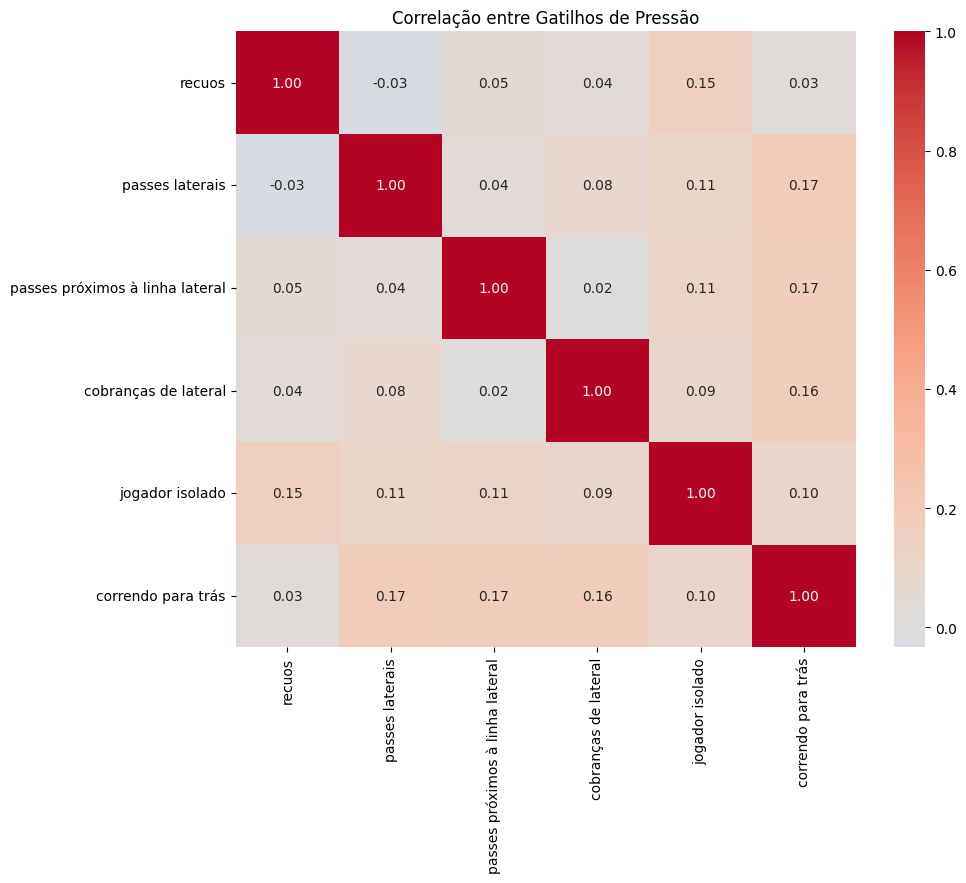

In [111]:
all_pressures = team_pressures_base.copy()

trigger_matrix = pd.DataFrame()

trigger_matrix["index"] = all_pressures["index"]

def build_trigger_flag(trigger_df, name):
    try:
        ids = set(trigger_df["pressure_index"])
    except KeyError:
        ids = set(trigger_df["index"])

    return trigger_matrix["index"].isin(ids).astype(int)

trigger_matrix["recuos"] = build_trigger_flag(
    backpasses,
    "recuos"
)

trigger_matrix["passes laterais"] = build_trigger_flag(
    lateral_passes,
    "passes laterais"
)

trigger_matrix["passes próximos à linha lateral"] = build_trigger_flag(
    sideline_passes,
    "passes próximos à linha lateral"
)

trigger_matrix["cobranças de lateral"] = build_trigger_flag(
    throw_ins,
    "cobranças de lateral"
)

trigger_matrix["jogador isolado"] = build_trigger_flag(
    open_area_passes,
    "jogador isolado"
)

trigger_matrix["correndo para trás"] = build_trigger_flag(
    body_angle_passes,
    "correndo para trás"
)

correlation_matrix = (
    trigger_matrix
    .drop(columns=["index"])
    .corr(method="pearson")
)

correlation_matrix.round(3)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlação entre Gatilhos de Pressão")
plt.show()

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


def get_value(row, col):
    prefixed = f"pressure_{col}"

    if prefixed in row.index:
        return row[prefixed]

    if col in row.index:
        return row[col]

    return np.nan


def build_model_base(trigger_sets):
    rows = []

    for trigger_name, df in trigger_sets.items():

        if df is None or df.empty:
            continue

        temp = df.copy()
        temp["trigger_type"] = trigger_name

        temp["model_match_id"] = temp.apply(
            lambda r: get_value(r, "match_id"), axis=1
        )
        temp["model_period"] = temp.apply(
            lambda r: get_value(r, "period"), axis=1
        )
        temp["model_t"] = temp.apply(
            lambda r: get_value(r, "t"), axis=1
        )
        temp["model_team_name"] = temp.apply(
            lambda r: get_value(r, "team_name"), axis=1
        )

        rows.append(temp)

    return pd.concat(rows, ignore_index=True)


trigger_sets = {
    "Recuos": backpasses,
    #"Passes laterais": lateral_passes,
    #"Passes próximos à lateral": sideline_passes,
    "Cobranças de lateral": throw_ins,
    #"Passes para goleiro": gk_passes,
    "Jogador isolado": open_area_passes,
    "Correndo para trás": body_angle_passes,
}

model_df = build_model_base(trigger_sets)
model_df = model_df[
    model_df["recovered"].notna()
].copy()

model_df["recovered"] = model_df["recovered"].astype(int)

feature_columns = ["trigger_type"]
optional_features = [
    #"receiver_speed",
    #"receiver_vx",
]

for col in optional_features:
    if col in model_df.columns:
        feature_columns.append(col)

X = model_df[feature_columns].copy()
X = pd.get_dummies(X, columns=["trigger_type"], drop_first=False, dtype=int)
X = X.fillna(0)
y = model_df["recovered"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

recovery_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(penalty='l2', solver='newton-cholesky', max_iter=1000, class_weight="balanced"))
])

recovery_model.fit(X_train, y_train)

y_pred = recovery_model.predict(X_test)
y_prob = recovery_model.predict_proba(X_test)[:, 1]

print("MODELO — RECUPERAÇÃO DA BOLA")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

recovery_coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": recovery_model.named_steps["logreg"].coef_[0]
})

recovery_coefficients["odds_ratio"] = np.exp(
    recovery_coefficients["coefficient"]
)

recovery_coefficients.sort_values(
    "odds_ratio",
    ascending=False
)

shot_model_df = []

for name, df in failed_outcome_dfs.items():

    if df is None or df.empty:
        continue

    if "recovered" not in df.columns:
        continue

    if "failed_shot_against" not in df.columns:
        continue

    temp = df.copy()
    temp["trigger_type"] = name

    temp = temp[
        ~temp["recovered"].astype(bool)
    ].copy()

    shot_model_df.append(temp)

shot_model_df = pd.concat(shot_model_df, ignore_index=True)

shot_model_df["failed_shot_against"] = (
    shot_model_df["failed_shot_against"].astype(int)
)
feature_columns_shot = ["trigger_type"]

for col in optional_features:
    if col in shot_model_df.columns:
        feature_columns_shot.append(col)

X_shot = shot_model_df[feature_columns_shot].copy()
X_shot = pd.get_dummies(
    X_shot,
    columns=["trigger_type"],
    drop_first=False
)

X_shot = X_shot.fillna(0)

y_shot = shot_model_df["failed_shot_against"]
X_train, X_test, y_train, y_test = train_test_split(
    X_shot,
    y_shot,
    test_size=0.25,
    random_state=42,
    stratify=y_shot
)

shot_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(penalty='l2', solver='newton-cholesky', max_iter=1000, class_weight="balanced"))
])

shot_model.fit(X_train, y_train)

y_pred = shot_model.predict(X_test)
y_prob = shot_model.predict_proba(X_test)[:, 1]

print("MODELO — FINALIZAÇÃO ADVERSÁRIA APÓS FALHA")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

shot_coefficients = pd.DataFrame({
    "feature": X_shot.columns,
    "coefficient": shot_model.named_steps["logreg"].coef_[0]
})

shot_coefficients["odds_ratio"] = np.exp(
    shot_coefficients["coefficient"]
)

shot_coefficients.sort_values(
    "odds_ratio",
    ascending=False
)

MODELO — RECUPERAÇÃO DA BOLA
[[100 388]
 [ 37 180]]
              precision    recall  f1-score   support

           0       0.73      0.20      0.32       488
           1       0.32      0.83      0.46       217

    accuracy                           0.40       705
   macro avg       0.52      0.52      0.39       705
weighted avg       0.60      0.40      0.36       705

ROC AUC: 0.5621600438165748
MODELO — FINALIZAÇÃO ADVERSÁRIA APÓS FALHA
[[1167  263]
 [  63   34]]
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      1430
           1       0.11      0.35      0.17        97

    accuracy                           0.79      1527
   macro avg       0.53      0.58      0.53      1527
weighted avg       0.90      0.79      0.83      1527

ROC AUC: 0.602278134236897


,feature,coefficient,odds_ratio
1,trigger_type_Correndo para trás,0.233029,1.262418
6,trigger_type_Todos os eventos de pressão coletiva,-0.014968,0.985144
2,trigger_type_Jogador isolado,-0.019061,0.981120
3,trigger_type_Passes laterais,-0.029265,0.971159
0,trigger_type_Cobranças de lateral,-0.066196,0.935948
5,trigger_type_Recuos,-0.103911,0.901305
4,trigger_type_Passes próximos à lateral,-0.162408,0.850094


In [135]:
def calculate_ridge_vif(X, alpha=1.0):
    """
    Calculates L2 (Ridge) adjusted Variance Inflation Factors.
    
    Parameters:
    X (pd.DataFrame): Dataframe containing all dummy columns.
    alpha (float): Regularization strength (equivalent to 1/C in scikit-learn).
    """
    # 1. Standardize/Center features to compute the correlation matrix
    X_centered = (X - X.mean()) / X.std()
    R = X_centered.corr().values
    
    # 2. Build the ridge-adjusted inverse matrix
    I = np.eye(R.shape[0])
    ridge_inv = np.linalg.inv(R + alpha * I)
    
    # 3. Compute the full Ridge VIF matrix
    V_lambda = ridge_inv @ R @ ridge_inv
    
    # 4. Extract diagonal elements (the VIF for each feature)
    vif_values = np.diag(V_lambda)
    
    return pd.Series(vif_values, index=X.columns)

# Example usage with your all-category dummy matrix (X_all)
# Note: alpha = 1 / C. If scikit-learn C=1.0, alpha=1.0.
ridge_vifs = calculate_ridge_vif(X, alpha=1.0)
print("           Tipo de Gatilho                  RVIF")
print(ridge_vifs)

           Tipo de Gatilho                  RVIF
trigger_type_Cobranças de lateral         0.223610
trigger_type_Correndo para trás           0.165871
trigger_type_Jogador isolado              0.207460
trigger_type_Passes laterais              0.192951
trigger_type_Passes próximos à lateral    0.215968
trigger_type_Recuos                       0.230857
dtype: float64
